# ⚡ SGEE: Smart Grid Energy Efficiency (GRU & Autoencoder)

**An Educational Deep Dive into Production-Grade Time-Series Forecasting & Anomaly Detection.**

Welcome to the interactive demo of SGEE. This notebook demonstrates how we use Recurrent Neural Networks (GRU) to forecast energy consumption and Autoencoders to detect inefficiencies in campus buildings.

---

## 1. 🛠️ Environment Setup

First, we clone the entire portfolio repository and navigate to this specific project. We then install the exact dependencies used in production.

In [ ]:
import os
import sys

# 1. Clone the Portfolio Repository
!git clone https://github.com/AgentBooster/portfolio-projects.git || echo "Repo already cloned"

# 2. Navigate to the Project Directory
PROJECT_PATH = "portfolio-projects/Machine_Learning_Deep_Learning/neural_time_series_forecaster_gru"
os.chdir(PROJECT_PATH)
print(f"✅ Working Directory: {os.getcwd()}")

# 3. Install Dependencies
!pip install -r requirements.txt
print("✅ Dependencies Installed!")

Cloning into 'portfolio-projects'...
remote: Enumerating objects: 755, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 755 (delta 18), reused 160 (delta 16), pack-reused 591 (from 1)
Receiving objects: 100% (755/755), 39.33 MiB | 33.73 MiB/s, done.
Resolving deltas: 100% (222/222), done.
✅ Working Directory: /content/portfolio-projects/Machine_Learning_Deep_Learning/neural_time_series_forecaster_gru/portfolio-projects/Machine_Learning_Deep_Learning/neural_time_series_forecaster_gru/portfolio-projects/Machine_Learning_Deep_Learning/neural_time_series_forecaster_gru
Ignoring tensorflow-metal: markers 'sys_platform == "darwin" and platform_machine == "arm64"' don't match your environment
✅ Dependencies Installed!


## 2. 📊 Data Visualization

Before predicting, let's understand the data. We use synthetic data generated to mirror real-world campus consumption patterns (2022-2026), including holidays, semesters, and weekends.

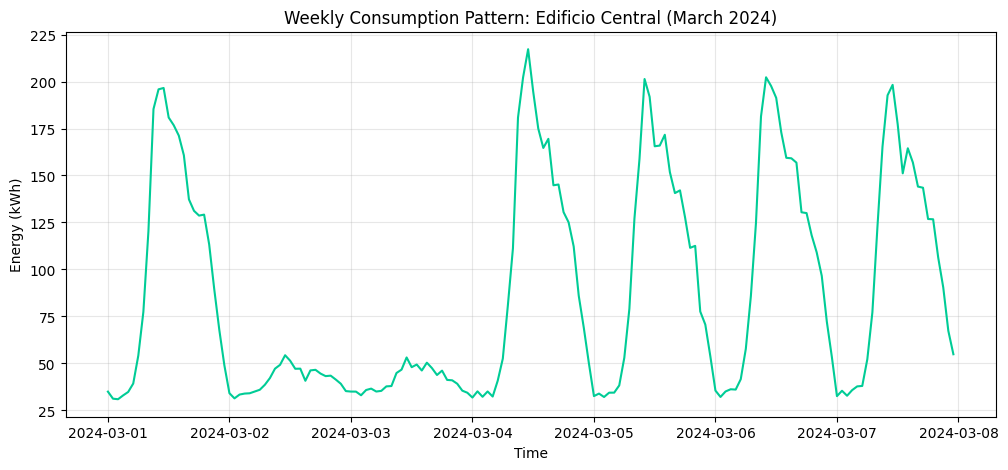

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load a sample of the data
df = pd.read_csv("data/processed/synthetic_2022_2026.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Plot one week of consumption for 'Edificio Central'
sample = df[(df['building_name'] == 'Edificio Central') & 
            (df['timestamp'] >= '2024-03-01') & 
            (df['timestamp'] < '2024-03-08')]

plt.figure(figsize=(12, 5))
sns.lineplot(data=sample, x='timestamp', y='consumption_kWh', color='#00CC96')
plt.title("Weekly Consumption Pattern: Edificio Central (March 2024)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.show()

## 3. 🧠 Model Architecture (The "Brains")

We use a **GRU forecaster** for each building. It predicts *expected* consumption based on calendar features (Hour, Day, Month, Holiday).

Let us load the pre-trained GRU model for **Edificio Apolonia**.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib

# Patch: ignore quantization_config in Dense configs (Keras 3 compatibility)
_dense_from_config = tf.keras.layers.Dense.from_config
def _patched_dense_from_config(config):
    config = dict(config)
    config.pop("quantization_config", None)
    return _dense_from_config(config)
tf.keras.layers.Dense.from_config = staticmethod(_patched_dense_from_config)

BUILDING = "Edificio Apolonia"

# Paths to artifacts
model_path = f"models/{BUILDING}_gru.keras"
scaler_path = f"models/{BUILDING}_scaler.pkl"

# Load them
model = load_model(model_path, compile=False)
scaler = joblib.load(scaler_path)

print(f"✅ Loaded GRU Model for {BUILDING}")
model.summary()

✅ Loaded GRU Model for Edificio Apolonia


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 168, 64)        │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,225 (94.63 KB)

 Trainable params: 24,225 (94.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. 🔮 Run Inference

We have built a CLI tool `src/predict_manual.py` that encapsulates the entire inference pipeline: 
1. Preprocessing inputs
2. Scaling
3. Model Prediction
4. Inverse Scaling
5. Anomaly Check.

Let's run it for a specific date.

In [ ]:
from src.predict_manual import get_prediction

# TARGET DATE: A Monday morning at 10:00 AM
DATE_TIME = "2024-05-20 10:00"

print(f"--- ⚡ AUDITING {BUILDING} @ {DATE_TIME} ---")
result = get_prediction(BUILDING, DATE_TIME)

if result:
    print(f"\nPrediction for {DATE_TIME}:")
    print(f"Predicted Consumption: {result['predicted']:.2f} kWh")
    print(f"Actual Consumption:    {result['actual']:.2f} kWh")
    print(f"Difference:            {result['difference']:.2f} kWh")

    status = "ANOMALY DETECTED" if result["is_anomaly"] else "Normal"
    print(f"\nAnomaly Status: {status}")
    print(f"Reconstruction Error: {result['reconstruction_error']:.4f} (Threshold: {result['threshold']:.4f})")

--- ⚡ AUDITING Edificio Apolonia @ 2024-05-20 10:00 ---
Loading data...
Data loaded.


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading Forecast Model...
Predicting Forecast...
Forecast Done.
Loading AE Model...
Predicting Anomalies...
AE Done.

Prediction for 2024-05-20 10:00:
Predicted Consumption: 30.33 kWh
Actual Consumption:    32.97 kWh
Difference:            -2.64 kWh

Anomaly Status: Normal
Reconstruction Error: 0.0311 (Threshold: 0.5527)


## 5. 📈 Single-Point Forecast Visualization

We visualize the actual consumption around the target time and overlay the model single-point forecast.

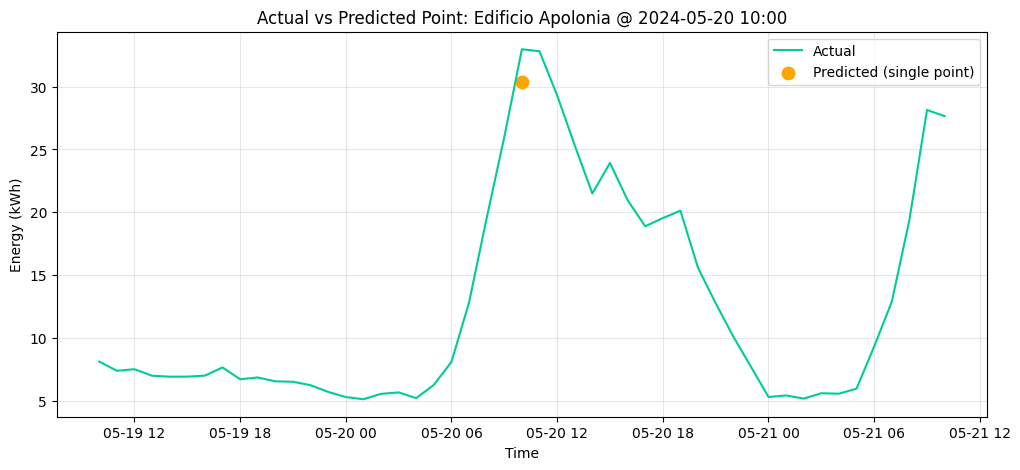

In [ ]:
# Plot a 48-hour window around the target timestamp and overlay the forecast point
if result:
    ts = pd.Timestamp(DATE_TIME)
    window = df[
        (df["building_name"] == BUILDING)
        & (df["timestamp"] >= ts - pd.Timedelta(hours=24))
        & (df["timestamp"] <= ts + pd.Timedelta(hours=24))
    ]

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=window, x="timestamp", y="consumption_kWh", color="#00CC96", label="Actual")
    plt.scatter([ts], [result["predicted"]], color="#FFA500", s=80, label="Predicted (single point)")
    plt.title(f"Actual vs Predicted Point: {BUILDING} @ {DATE_TIME}")
    plt.ylabel("Energy (kWh)")
    plt.xlabel("Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 6. 🚀 Dashboard Preview

For a full interactive UI, you can launch either the Gradio dashboard or the Next.js Dashboard 2.0.

**Option A — Gradio (fast local demo):**
```bash
python src/dashboard/gradio_app.py
```

**Option B — Dashboard 2.0 (Next.js + API):**
```bash
# Terminal 1 (API)
uvicorn src.api.main:app --reload --port 8080

# Terminal 2 (Frontend)
npm run dev
```

This notebook focuses on the core inference pipeline behind those interfaces.